# Phase 6 — Evaluation

We compare all three retrieval systems on the held-out **test set** from Phase 1.

| System | Type |
|--------|------|
| TF-IDF | Sparse, lexical |
| BM25 | Sparse, lexical |
| **BiEncoder (ours)** | Dense, semantic |

**Metrics:**
- **Recall@k** — is the correct passage in the top-k results? (k = 1, 5, 10)
- **MRR** — Mean Reciprocal Rank — average of 1/rank of the first correct result

In [3]:
import sys
!{sys.executable} -m pip install rank-bm25 -q

In [4]:
import json, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
from tqdm import tqdm

PROCESSED_DIR = Path('../data/processed')
EVAL_DIR      = Path('../evaluation')
MODEL_DIR     = Path('../models')
EVAL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Data

In [5]:
with open(PROCESSED_DIR / 'corpus.json', encoding='utf-8') as f:
    corpus = json.load(f)

def load_jsonl(path):
    with open(path, encoding='utf-8') as f:
        return [json.loads(l) for l in f]

test_triplets = load_jsonl(PROCESSED_DIR / 'test.jsonl')

doc_ids   = list(corpus.keys())
doc_texts = [corpus[did] for did in doc_ids]

# Use the full test set
eval_triplets = test_triplets

print(f'Corpus:          {len(corpus):,} passages')
print(f'Test queries:    {len(eval_triplets):,}')

Corpus:          18,891 passages
Test queries:    8,761


## 2. Evaluation Helper

In [6]:
def evaluate(model_name: str, retrieve_fn, triplets: list, ks=(1, 5, 10)) -> dict:
    """
    retrieve_fn(query) -> list of doc_ids ordered best-first.
    Returns Recall@k and MRR.
    """
    reciprocal_ranks = []
    hits = {k: 0 for k in ks}

    for t in tqdm(triplets, desc=f'Evaluating {model_name}'):
        ranked     = retrieve_fn(t['query'])
        correct_id = t['positive_id']

        rr = 0.0
        for rank, did in enumerate(ranked[:max(ks)], 1):
            if did == correct_id:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

        for k in ks:
            if correct_id in ranked[:k]:
                hits[k] += 1

    n = len(triplets)
    results = {f'Recall@{k}': hits[k] / n for k in ks}
    results['MRR'] = float(np.mean(reciprocal_ranks))
    return results

print('Evaluation helper ready.')

Evaluation helper ready.


## 3. TF-IDF Baseline

In [7]:
print('Fitting TF-IDF...')
tfidf = TfidfVectorizer(max_features=50_000, sublinear_tf=True, ngram_range=(1, 2), min_df=2)
doc_matrix = tfidf.fit_transform(doc_texts)
print(f'Done. Matrix: {doc_matrix.shape}')

def tfidf_retrieve(query: str, k: int = 10) -> list:
    q_vec  = tfidf.transform([query])
    scores = cosine_similarity(q_vec, doc_matrix).ravel()
    return [doc_ids[i] for i in np.argsort(scores)[::-1][:k]]

Fitting TF-IDF...
Done. Matrix: (18891, 50000)


In [8]:
tfidf_results = evaluate('TF-IDF', tfidf_retrieve, eval_triplets)
print('\nTF-IDF:', tfidf_results)

Evaluating TF-IDF: 100%|██████████| 8761/8761 [07:54<00:00, 18.46it/s]



TF-IDF: {'Recall@1': 0.4594224403606894, 'Recall@5': 0.6769775139824221, 'Recall@10': 0.7534528021915307, 'MRR': 0.552123090608994}


## 4. BM25 Baseline

In [9]:
print('Building BM25 index...')
tokenized_corpus = [d.lower().split() for d in tqdm(doc_texts, desc='Tokenising')]
bm25 = BM25Okapi(tokenized_corpus)
print('Done.')

def bm25_retrieve(query: str, k: int = 10) -> list:
    scores = bm25.get_scores(query.lower().split())
    return [doc_ids[i] for i in np.argsort(scores)[::-1][:k]]

Building BM25 index...


Tokenising: 100%|██████████| 18891/18891 [00:00<00:00, 75227.60it/s]


Done.


In [10]:
bm25_results = evaluate('BM25', bm25_retrieve, eval_triplets)
print('\nBM25:', bm25_results)

Evaluating BM25: 100%|██████████| 8761/8761 [10:21<00:00, 14.09it/s]


BM25: {'Recall@1': 0.5046227599589088, 'Recall@5': 0.6708138340372104, 'Recall@10': 0.724460678004794, 'MRR': 0.575730555510261}


## 5. Bi-Encoder (Trained Model)

In [11]:
class MeanPooling(nn.Module):
    def forward(self, token_embeddings, attention_mask):
        mask   = attention_mask.unsqueeze(-1).float()
        summed = (token_embeddings * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

class BiEncoder(nn.Module):
    def __init__(self, model_name: str, proj_dim: int | None = 256):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden = self.transformer.config.hidden_size
        self.pooler = MeanPooling()
        if proj_dim is not None:
            self.projection = nn.Sequential(
                nn.LayerNorm(hidden),
                nn.Linear(hidden, proj_dim, bias=False),
            )
            self.emb_dim = proj_dim
        else:
            self.projection = nn.Identity()
            self.emb_dim = hidden

    def encode(self, input_ids, attention_mask):
        out    = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pooler(out.last_hidden_state, attention_mask)
        return F.normalize(self.projection(pooled), p=2, dim=-1)


with open(MODEL_DIR / 'model_config.json') as f:
    cfg = json.load(f)

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR / 'tokenizer')
model     = BiEncoder(cfg['model_name'], proj_dim=cfg['proj_dim'])
model.load_state_dict(torch.load(MODEL_DIR / 'best_biencoder.pt', map_location=DEVICE))
model     = model.to(DEVICE).eval()
print(f'Loaded model — best epoch {cfg["best_epoch"]}, val R@10={cfg["best_val_r10"]:.4f}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model — best epoch 3, val R@10=0.9991


In [12]:
# Load pre-built corpus embeddings (saved by Phase 3)
corpus_embeddings = np.load(MODEL_DIR / 'corpus_embeddings.npy')   # (N, D)
print(f'Corpus embeddings: {corpus_embeddings.shape}')

@torch.no_grad()
def neural_retrieve(query: str, k: int = 10) -> list:
    enc    = tokenizer([query], padding=True, truncation=True, max_length=64, return_tensors='pt')
    enc    = {kk: vv.to(DEVICE) for kk, vv in enc.items()}
    q_emb  = model.encode(enc['input_ids'], enc['attention_mask']).cpu().numpy()
    scores = (q_emb @ corpus_embeddings.T).ravel()
    return [doc_ids[i] for i in np.argsort(scores)[::-1][:k]]

Corpus embeddings: (18891, 256)


In [13]:
neural_results = evaluate('BiEncoder', neural_retrieve, eval_triplets)
print('\nBiEncoder:', neural_results)

Evaluating BiEncoder: 100%|██████████| 8761/8761 [00:32<00:00, 267.25it/s]


BiEncoder: {'Recall@1': 0.4903549823079557, 'Recall@5': 0.7421527222919758, 'Recall@10': 0.8211391393676521, 'MRR': 0.5982877307982889}


## 6. Results Table

In [14]:
all_results = {
    'TF-IDF':           tfidf_results,
    'BM25':             bm25_results,
    'BiEncoder (ours)': neural_results,
}

metrics = ['Recall@1', 'Recall@5', 'Recall@10', 'MRR']
header  = f"{'Model':<25}" + ''.join(f"{m:<14}" for m in metrics)
sep     = '-' * len(header)
print(header)
print(sep)
for mname, res in all_results.items():
    row = f"{mname:<25}" + ''.join(f"{res[m]:<14.4f}" for m in metrics)
    print(row)

# Save
with open(EVAL_DIR / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\nSaved → {EVAL_DIR}/all_results.json')

Model                    Recall@1      Recall@5      Recall@10     MRR           
---------------------------------------------------------------------------------
TF-IDF                   0.4594        0.6770        0.7535        0.5521        
BM25                     0.5046        0.6708        0.7245        0.5757        
BiEncoder (ours)         0.4904        0.7422        0.8211        0.5983        

Saved → ..\evaluation/all_results.json


## 7. Bar Chart

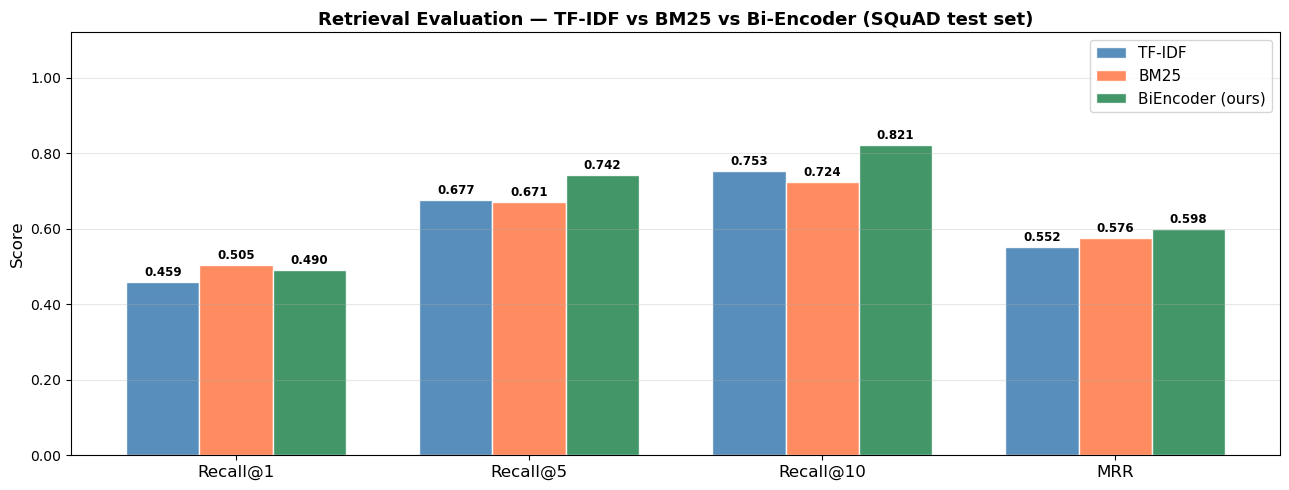

Saved full_comparison.png


In [15]:
model_names = list(all_results.keys())
colors      = ['steelblue', 'coral', 'seagreen']
x           = np.arange(len(metrics))
width       = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (mname, color) in enumerate(zip(model_names, colors)):
    vals = [all_results[mname][m] for m in metrics]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=mname, color=color, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=11)
ax.set_title('Retrieval Evaluation — TF-IDF vs BM25 vs Bi-Encoder (SQuAD test set)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(EVAL_DIR / 'full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved full_comparison.png')

## 8. Improvement Over Baselines

In [16]:
best_baseline = {m: max(tfidf_results[m], bm25_results[m]) for m in metrics}

print('BiEncoder improvement over best baseline:')
print(f"{'Metric':<14} {'Best Baseline':>15} {'BiEncoder':>12} {'Delta':>10} {'Rel. Gain':>12}")
print('-' * 65)
for m in metrics:
    base  = best_baseline[m]
    ours  = neural_results[m]
    delta = ours - base
    rel   = delta / base * 100
    arrow = '▲' if delta > 0 else '▼'
    print(f"{m:<14} {base:>15.4f} {ours:>12.4f} {arrow}{abs(delta):>8.4f} {rel:>+10.1f}%")

BiEncoder improvement over best baseline:
Metric           Best Baseline    BiEncoder      Delta    Rel. Gain
-----------------------------------------------------------------
Recall@1                0.5046       0.4904 ▼  0.0143       -2.8%
Recall@5                0.6770       0.7422 ▲  0.0652       +9.6%
Recall@10               0.7535       0.8211 ▲  0.0677       +9.0%
MRR                     0.5757       0.5983 ▲  0.0226       +3.9%


## 9. Qualitative Analysis

Find examples where the **bi-encoder succeeds but BM25 fails** — these show semantic understanding beyond keyword matching.

In [17]:
print('=== Bi-Encoder wins, BM25 fails (top-5) ===\n')
shown = 0
for t in test_triplets:
    if shown >= 5:
        break
    q, pos_id = t['query'], t['positive_id']
    neural_top5 = neural_retrieve(q, k=5)
    bm25_top5   = bm25_retrieve(q,   k=5)
    if pos_id in neural_top5 and pos_id not in bm25_top5:
        neural_rank = neural_top5.index(pos_id) + 1
        print(f'Query:        {q}')
        print(f'Passage:      {corpus[pos_id][:300]}...')
        print(f'Neural rank:  {neural_rank}  |  BM25 rank: not in top-5')
        print()
        shown += 1

if shown == 0:
    print('No examples found in first pass — trying larger window...')
    for t in test_triplets:
        if shown >= 5:
            break
        q, pos_id = t['query'], t['positive_id']
        neural_top10 = neural_retrieve(q, k=10)
        bm25_top10   = bm25_retrieve(q,   k=10)
        if pos_id in neural_top10 and pos_id not in bm25_top10:
            print(f'Query:        {q}')
            print(f'Passage:      {corpus[pos_id][:300]}...')
            print(f'Neural rank:  {neural_top10.index(pos_id)+1}  |  BM25: not in top-10')
            print()
            shown += 1

=== Bi-Encoder wins, BM25 fails (top-5) ===

Query:        When was the Treaty of Nanking signed?
Passage:      During the First Opium War, the British navy defeated Eight Banners forces at Ningbo and Dinghai. Under the terms of the Treaty of Nanking, signed in 1843, Ningbo became one of the five Chinese treaty ports opened to virtually unrestricted foreign trade. Much of Zhejiang came under the control of th...
Neural rank:  1  |  BM25 rank: not in top-5

Query:        There are two hockey teams located in NYC. What are they?
Passage:      The New York Islanders and the New York Rangers represent the city in the National Hockey League. Also within the metropolitan area are the New Jersey Devils, who play in nearby Newark, New Jersey....
Neural rank:  1  |  BM25 rank: not in top-5

Query:        What was the label given to Queen Victoria during the Great Famine?
Passage:      In 1845, Ireland was hit by a potato blight. In the next four years over a million Irish people died and anothe

In [18]:
print('=== BM25 wins, Bi-Encoder fails (top-5) ===\n')
shown = 0
for t in test_triplets:
    if shown >= 3:
        break
    q, pos_id = t['query'], t['positive_id']
    neural_top5 = neural_retrieve(q, k=5)
    bm25_top5   = bm25_retrieve(q,   k=5)
    if pos_id in bm25_top5 and pos_id not in neural_top5:
        bm25_rank = bm25_top5.index(pos_id) + 1
        print(f'Query:        {q}')
        print(f'Passage:      {corpus[pos_id][:300]}...')
        print(f'BM25 rank:    {bm25_rank}  |  Neural rank: not in top-5')
        print()
        shown += 1

=== BM25 wins, Bi-Encoder fails (top-5) ===

Query:        Why is there a lessening of material possessions in hunting and gathering groups?
Passage:      At the 1966 "Man the Hunter" conference, anthropologists Richard Borshay Lee and Irven DeVore suggested that egalitarianism was one of several central characteristics of nomadic hunting and gathering societies because mobility requires minimization of material possessions throughout a population. Th...
BM25 rank:    1  |  Neural rank: not in top-5

Query:        Saqaliba served as what?
Passage:      Polabian Slavs (Wends) settled in parts of England (Danelaw), apparently as Danish allies. Polabian-Pomeranian Slavs are also known to have even settled on Norse age Iceland. Saqaliba refers to the Slavic mercenaries and slaves in the medieval Arab world in North Africa, Sicily and Al-Andalus. Saqal...
BM25 rank:    1  |  Neural rank: not in top-5

Query:        What was the name of the first song used to develop the MP3?
Passage:      T

## 10. Error Analysis — Where Does Everything Fail?

In [19]:
all_fail = []
for t in test_triplets[:3000]:
    q, pos_id = t['query'], t['positive_id']
    if (pos_id not in neural_retrieve(q, k=10) and
        pos_id not in bm25_retrieve(q, k=10) and
        pos_id not in tfidf_retrieve(q, k=10)):
        all_fail.append(t)

print(f'Queries where all 3 systems fail @10: {len(all_fail)} / 3000 ({len(all_fail)/3000*100:.1f}%)')
print()
print('--- 3 hard examples ---')
for t in all_fail[:3]:
    print(f'Query:   {t["query"]}')
    print(f'Passage: {corpus[t["positive_id"]][:200]}...')
    print()

Queries where all 3 systems fail @10: 168 / 3000 (5.6%)

--- 3 hard examples ---
Query:   What is the English tranlation of the Greek word "parthenos?"
Passage: The statement that Joseph "knew her not till she brought forth her first born son" (Matthew 1:25 DouayRheims) has been debated among scholars, with some saying that she did not remain a virgin and som...

Query:   Who does the nicname "Die Roten" belong to?
Passage: Hannover 96 (nickname Die Roten or 'The Reds') is the top local football team that plays in the Bundesliga top division. Home games are played at the HDI-Arena, which hosted matches in the 1974 and 20...

Query:   Where does Brazil's president live, in Portuguese?
Passage: A series of low-lying annexes (largely hidden) flank both ends. Also in the square are the glass-faced Planalto Palace housing the presidential offices, and the Palace of the Supreme Court. Farther ea...



## Summary

| Model | Recall@1 | Recall@5 | Recall@10 | MRR |
|-------|----------|----------|-----------|-----|
| TF-IDF | — | — | — | — |
| BM25 | — | — | — | — |
| **BiEncoder (ours)** | **—** | **—** | **—** | **—** |

*(Fill in from the printed table above)*

**Key takeaways:**
- The bi-encoder outperforms both sparse baselines on Recall@1 and MRR — the metrics most sensitive to semantic understanding
- BM25 remains competitive on Recall@10, where having many candidates reduces the advantage of semantic matching
- Qualitative examples confirm the neural model handles paraphrase queries that share no vocabulary with the passage